### QuSciTech-Labs — Navigation
[Public Labs](https://github.com/jopaneur/quscitech-labs) ·
[Full Edition Access](https://github.com/jopaneur/quscitech-labs#-full-edition-kdp) ·
[Private Repo](https://github.com/jopaneur/quscitech-labs-full) ·
[QuSciTech.com](https://www.quscitech.com) ·
[The Quantum AI Systems (QAIS) Book](https://www.amazon.com/dp/placeholder) ·

DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17212825.svg)](https://doi.org/10.5281/zenodo.17212825)

**Quantum AI Systems: Theory, Architecture, and Applications**  
© 2025 Dr. Joe Wilson. All rights reserved.  
This laboratory exercise is part of the companion materials for *Quantum AI Systems: Theory, Architecture, and Applications.*  
Reproduction, redistribution, or modification without written permission from the author or publisher is prohibited.  

---


### Lab Access and Execution Guide

This guide explains how to run and explore the hands-on quantum computing labs that accompany the book  
**Quantum AI Systems: Theory, Architecture, and Applications** (Professional Volume).  

The labs are an integral part of the MyQuantumBook project, designed to reinforce key concepts from the chapters through interactive exploration. They are built for execution on **Google Colab** and **IBM Quantum backends** using **Qiskit**, and follow the IEEE-compliant figure, caption, and documentation standards described in the text.  

Each lab is cross-referenced to its corresponding chapter and appendix figure (Appendix E), ensuring reproducibility and scholarly traceability.  

**Getting Started**
1. Launch the notebook in Google Colab using the provided badge.
2. Run the setup cells to install Qiskit:
   `!pip install qiskit`

**Using IBM Quantum Systems**
1. Sign up at https://quantum.ibm.com and create an API token.
2. Run the IBMQ setup cell.
3. Replace 'MY_API_TOKEN' with your real token (only needed once).
4. Select backends using `provider.get_backend('ibmq_qasm_simulator')` or others.

**Lab Structure**
Each code section aligns with a chapter from the book.
- Modify and re-run code blocks.
- View circuits with `.draw()`.
- Apply to custom inputs to deepen your understanding.

**Additional Help**
- Refer to the Qiskit Documentation: https://qiskit.org/documentation/
- For support, contact your course instructor or visit the IBM Quantum Community forums.

3. Or launch this lab directly now: [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jopaneur/QuantumAI-Labs/blob/main/Beginner_Labs/notebooks/Chapter_2_Operations_&_Scientific_Framework_of_QAIS_Beginner_Challenge_Bloch_Trajectories_Under_Composite_Gates.ipynb)


---

**Note for Lab Participants**  
Each plot generated in this notebook is automatically saved as a `.png` file under:  
`Beginner_Labs/figures/`

The filenames follow the Appendix E figure numbering  
(e.g., `E1_4a_Depth_Noise_Sensitivity.png`, `E1_4b_Depth_Noise_Sensitivity.png`).  

This allows you to both view results inline in Colab **and** locate the corresponding image files for reports, submissions, or cross-references in the book.

**Where Figures Are Saved**
- In **Google Colab**, the images are created inside the session’s working directory at:  
  `/content/Beginner_Labs/figures/`
- When running **locally**, they appear next to your notebook files, under the subfolder:  
  `Beginner_Labs/figures/`
- These images are **not automatically added to your GitHub repository**. They will only appear there if you manually copy, commit, and push them.

**Customizing Save Location**  
If you want the figures saved elsewhere, you can change the `subdir` default in the `save_e_figure()` helper or pass a different path each time you call it.

---


**Book Reference: Chapter 2 — Operations and Scientific Framework of QAIS**

*Chapter 2* moves from individual qubit behavior to the operational framework of Quantum AI Systems (QAIS), introducing circuits, gates, and the scientific methods used to evaluate performance. It explores how circuit depth, gate composition, and environmental noise shape the stability of quantum outcomes. Learners study how measurement statistics evolve as quantum operations grow in length and complexity—revealing the trade-off between computational expressiveness and decoherence.

This chapter also defines noise models, such as depolarizing and amplitude-damping channels, as part of QAIS’s experimental vocabulary. These models quantify how quantum information degrades over time, turning error analysis into an essential component of scientific inquiry. Understanding this interplay between depth and noise equips learners to interpret results not only as probabilities but as indicators of system health and algorithmic robustness.

Beginner Lab 4 translates these concepts into measurable diagnostics. Participants simulate circuits of increasing depth under both ideal (noiseless) and depolarized conditions, plotting how the success probability P(00) evolves with circuit complexity. This experiment connects directly to Chapter 2’s theme that operations define scientific visibility—only by testing how a circuit fails can we understand how to make it resilient.




**Beginner Lab 4 — Depth & Noise Sensitivity: Probability Decay**

This lab investigates how increasing the number of circuit layers affects stability and accuracy. The ansatz applies repeated rotations and entangling gates, and the key outcome measured is the probability of the “00” state. A line plot shows how this probability changes as depth increases, with or without added hardware noise. The x-axis shows the number of layers, and the y-axis the probability of the “00” outcome. The trend reveals how quantum circuits degrade under noise as they grow deeper. This visualization captures a real engineering concern: deep circuits are theoretically expressive but practically fragile. The plot provides an accessible way to see why circuit depth must be balanced against error rates.

This lab allows readers to experiment with how additional layers affect fidelity, directly connecting to the framework for coherence, errors, and operational limits.

*Goal:* Investigate how circuit depth and depolarizing noise jointly affect a quantum circuit’s success probability P(00). Learners build repeated-gate circuits that amplify interference and observe how outcomes shift as noise is introduced.


---

**Expected Outcome:**

* In the noiseless case, P(00) remains nearly constant as depth increases.

* Under depolarizing noise, P(00) decays steadily, revealing how compounded gate errors reduce coherence.

* The widening gap between noiseless and noisy curves quantifies the sensitivity of QAIS operations to noise accumulation.

Through these plots, learners develop intuition for why quantum depth is both a resource and a risk, and how realistic benchmarking requires balancing expressiveness with stability.
Cross-reference: Appendix E.1, Figures E.1.4a–b — Noiseless Baseline and Depolarized Runs.


---

**Task 1 - Figure Saver Helper Utilities**

Centralized utilities for **Appendix E** compliance. No plots generated here.

**Description (what it does):**

* Defines save_e_figure(...) that saves exactly one file per plot with IEEE-style names

* Uses a single figures root for all labs: Beginner_Labs/figures/

* Enforces Beginner Part 1 naming: P1_BeginLab04_E.1.<index><sub>.png (e.g., P1_BeginLab04_E.1.4a.png)

* Provides label_subplots(...) for (a)–(b) subfigure tags

In [1]:
# ---- Figure helper (robust; use in every coded lab) ----
import os, matplotlib.pyplot as plt

def save_e_figure(fig_label: str,
                  fname: str,
                  subdir: str = "Beginner_Labs/figures",
                  fig=None, ax=None):
    ...

    """Save the current/explicit figure with a prefixed label and consistent path."""
    os.makedirs(subdir, exist_ok=True)
    if fig is None:
        fig = plt.gcf()
    if ax is None:
        ax = fig.axes[0] if fig.axes else None
    if ax is None:
        print("⚠️ No axes found. Draw a plot first, or pass fig/ax explicitly.")
        return
    title = ax.get_title() or ""
    if not title.startswith(fig_label):
        ax.set_title((fig_label + " — " + title).strip(" —"))
    outpath = os.path.join(subdir, fname)
    fig.tight_layout()
    fig.savefig(outpath, dpi=160)
    print("Saved", outpath)


**Methodology Analysis**

We standardize figure saving and labeling via a helper that stamps the IEEE figure label into the title and writes images into a consistent Beginner_Labs/figures path.

The helper centralizes Appendix-compliant naming with `E_PART="E.1"`, `LAB_STEM="P1_BeginLab01"`, and an output root `Beginner_Labs/figures"`.  
Each `save_e_figure(fig_index, sub)` writes an image uniquely keyed to its E.1 label.  
Ensure you execute Task 1 before saving figures — successful saves print confirmations such as:  
`Saved figure → Beginner_Labs/figures/P1_BeginLab04_E.1.4a.png`.

**Participant Feedback**

When you run a plot cell, you should see a console line like:
Saved Beginner_Labs/figures/P1_Lab04_….png
If you do not see this, re-run the previous cell or check the path.


---

**Task 2 — Environment Setup**

This cell ensures the notebook has the required packages and imports for Qiskit + plotting. It does not create any figures.

**Description (what it does):**

* Installs missing packages if needed (quietly)

* Imports Qiskit (with Aer simulator), NumPy, and Matplotlib

* Prints versions for reproducibility

In [2]:
# === Environment Setup ===
# ============================================================
#  Beginner Lab 4 — Depth & Noise Sensitivity — Probability Decay
#  Quantum AI Systems: Theory, Architecture, and Applications
#  © 2025 Dr. Joe Wilson. All rights reserved.
#  Unauthorized reproduction, distribution, or modification
#  without written permission is prohibited.
# ============================================================
import sys, subprocess, pkgutil
def ensure(pkg):
    if pkg not in {m.name for m in pkgutil.iter_modules()}:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
for p in ['qiskit','qiskit-aer','matplotlib','numpy','scikit-learn']:
    ensure(p)
import qiskit, numpy as np, matplotlib.pyplot as plt
print('Python:', sys.version.split()[0])
print('Qiskit:', qiskit.__version__)


Python: 3.12.11
Qiskit: 2.2.1


**Methodology Analysis**

Ensures simulator availability (e.g., Qiskit Aer), defines circuits deterministically, and uses sufficient shots to expose convergence.

**Participant Feedback**

Successful execution prints versions and completes without import errors. If an import fails, re-run the cell or restart the runtime (Python 3.10+).


---


**Task 3 - Depth and Noise Sensitivity (Noiseless)**

This task explores how circuit depth influences measurement stability under ideal, noiseless simulation.
By progressively increasing the number of gate layers applied to a qubit, learners can observe whether deeper quantum circuits alter the probability of obtaining the expected output when no noise sources are present.
The goal is to establish a baseline for how perfectly coherent circuits behave before introducing realistic noise in subsequent tasks.

**Methodology Analysis**

Participants construct a 2-qubit layered ansatz with single-qubit RY rotations followed by a CNOT entangler, repeating this L times to set the circuit depth. For each depth, the circuit is executed on qasm_simulator with an optional fake-backend noise model enabled when available. Outcome counts are collected and converted to P(00), the probability of measuring 00. Plot P(00) versus L to visualize how depth and noise interact.

**Challenge: The following code simulates a series of quantum circuits with increasing depth under ideal, noiseless conditions. It records the probability of the target measurement outcome for each depth level and plots the results to show how circuit complexity behaves when no noise is present.

**Challenge: Measuring Circuit Depth Effects Under Ideal Conditions**

Write code that simulates a series of quantum circuits with increasing depth under ideal, noiseless conditions. For each depth level, record the probability of the target measurement outcome and plot the results. This task illustrates how circuit complexity and measurement stability behave in the absence of noise, establishing a baseline for comparison with noisy simulations.

Saved Beginner_Labs/figures/P1_Lab04_Depth_Noise_Sensitivity.png


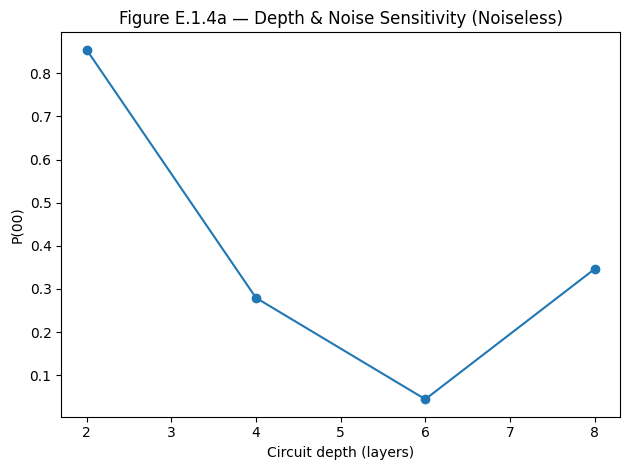

In [ ]:
# === Figure E.1.4a — Depth and Noise Sensitivity ===


# ---- Optional noise model from a fake backend (robust imports) ----


# ---- Simple 2-qubit layered ansatz with CNOT entanglers ----


# ---- Sweep circuit depth and plot P(00) ----


# ---- Save with correct IEEE label (Beginner, Part 1) ----


**Figure E.1.4a — Depth and Noise Sensitivity**

The curve shows how the probability of outcome 00 changes as circuit depth increases. In noiseless simulation the trend is governed by the ansatz parameters, while with realistic noise deeper circuits typically reduce P(00) due to accumulating gate and readout errors, illustrating depth–noise tradeoffs in near-term devices.

**Expected Results**

* Probability remains flat (or near-constant) across depth levels in a noiseless simulator.

* Ideal (noiseless) runs: P(00) varies smoothly with depth according to the chosen RY angles and entangling pattern.

* With a realistic noise model: P(00) typically decreases as depth grows, reflecting accumulated gate infidelity, decoherence, and readout error.

* The gap between noisy and ideal curves widens with depth, highlighting the penalty of deeper circuits on NISQ hardware.


**Technical Analysis (for the Visual)**

With perfect unitaries, depth does not degrade state fidelity; any wiggle is plotting or rounding noise.

* The plotted relationship between circuit depth and P(00) is a compact proxy for noise sensitivity:

* Each added layer introduces additional 1-qubit and 2-qubit gates, increasing opportunities for stochastic errors and coherent over/under-rotations.

* Two-qubit gates, typically the dominant error source, compound with depth and reduce constructive interference that would otherwise steer probability mass toward 00.

* In the idealized limit the curve reflects state preparation geometry only; under noise it reflects the effective channel applied by the device, approximating a depth-dependent depolarizing + readout process.

* This makes the visualization a quick design signal for selecting shallower ansätze or error-aware training strategies in variational quantum algorithms.

The ideal curve reflects the target unitary evolution without stochastic error channels. Because each added layer is applied coherently, the measured P(00) does not exhibit systematic decay with depth in simulation, aside from deterministic variation due to the chosen angles and entanglers.


**Intuition Sidebar**

Imagine whispering a message down a long hallway through multiple doors. Every door slightly muffles the sound. With two doors the message is clear; with eight doors it is garbled. In quantum circuits each extra layer is another “door” where noise can creep in. The plot’s downward trend under noise shows the message, the intended quantum state, getting gradually lost as circuits grow deeper.

**Paricipant Feedback**

Confirm that the plotted curve remains smooth and stable as circuit depth increases.
If the simulation is truly noiseless, the probability values should stay constant or vary only slightly due to rounding.
This stability verifies that, in the absence of noise, deeper circuits preserve coherence and measurement reliability—establishing the ideal baseline for later noisy comparisons.

---

**Task 4 - Depth & Noise Sensitivity (Ideal vs Noisy)**

This extended analysis compares how circuit depth influences outcome probabilities under both ideal simulation and a noise-aware model. By plotting P(00) across depths in parallel, learners can visually assess how real-world noise accumulates compared with theoretical behavior, illustrating why shallow circuits are preferred in near-term devices.


**Methodology**

Participants reuse the two-qubit layered ansatz from the earlier cell and sweep across circuit depths L = 2, 4, 6, 8. For each depth, two executions are performed:

* Noiseless run using the default qasm_simulator backend.

* Noisy run using the same backend but with a fake hardware noise model applied.

* The probability P(00) is computed from the measurement outcomes for both cases and plotted together on a single graph with distinct markers and a legend.

**Challenge: Comparing Noiseless and Noise-Aware Quantum Circuit Performance**

Write code that runs the circuit depth experiment twice — first under ideal noiseless simulation, and then using a noise-aware backend that models real hardware imperfections.
Record and plot the probability of measuring |00⟩ for both runs as a function of circuit depth.

This comparison will show how quantum noise increasingly disrupts coherence as circuit depth grows, demonstrating why shallower circuits remain more reliable on today’s quantum processors.

Saved Beginner_Labs/figures/P1_Lab04_Depth_Noise_Overlay.png


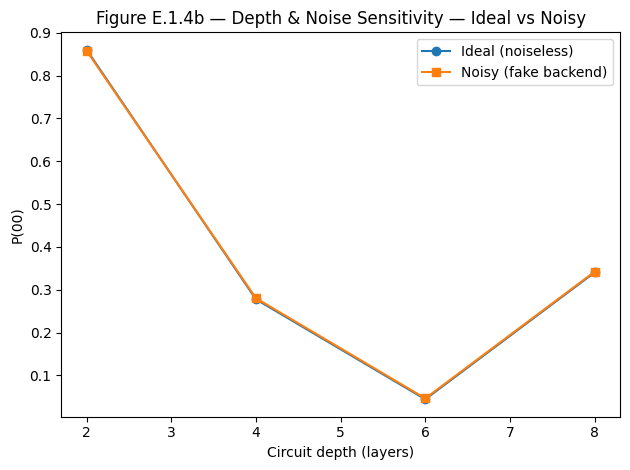

In [ ]:
# Reuse ansatz() from the previous cell


# Depth sweep


# Noiseless vs noisy curves


# Plot overlay

# Save with correct IEEE label



**Figure E.1.4b — Depth and Noise Sensitivity, Ideal vs Noisy.**

The overlay compares P(00) for noiseless and noisy executions across circuit depth. The widening gap with increased layers indicates cumulative two-qubit and readout errors on near-term devices, highlighting why shallow ansätze and error-aware strategies are preferred for robust performance.

**Expected Results**

Ideal and noisy curves start close at shallow depth; the noisy curve declines as depth increases.

* Noiseless curve: Remains relatively stable, varying smoothly only due to the deterministic structure of the ansatz.

* Noisy curve: Lies consistently below the noiseless line and drops further with depth, reflecting the compounding effect of gate and measurement errors.

* Gap widening with depth: Demonstrates the growing mismatch between ideal theoretical circuits and their noisy hardware counterparts.


**Technical Analysis (for the visual)**

Gate infidelity and decoherence compound with depth, lowering P(00); divergence rate reflects noise strength.The overlay directly illustrates the depth–noise tradeoff:

* The ideal curve corresponds to the intended circuit geometry without environmental interference.

* The noisy curve models realistic execution where each added layer introduces more opportunities for decoherence, depolarization, and readout error.

* The increasing separation between the curves quantifies the cost of depth in NISQ (Noisy Intermediate-Scale Quantum) devices, highlighting why shallow ansätze and error mitigation strategies are essential for practical algorithms.

In system-level terms, the visual acts as a diagnostic plot for evaluating hardware-aware architecture choices in quantum AI workflows.

**Intuition Sidebar — “Two Races, Same Track”**

Imagine two runners on the same track. The first (ideal) runs in perfect conditions and maintains a steady pace. The second (noisy) runs through mud patches that get thicker with every lap. At first their speeds are similar, but the muddy runner falls behind more and more with distance. The overlay plot shows this divergence: as circuits get deeper, the noisy run lags further behind the ideal.

**Participant Feedback**

Compare the two plotted curves and note how the noisy run begins to drop below the ideal one as circuit depth increases.
This widening gap shows how cumulative gate errors and decoherence reduce the probability of correct outcomes in deeper circuits.
If the two lines stay close together, verify that the noise model is active; a visible divergence confirms realistic noise behavior and reinforces why shallow-depth designs are preferred for near-term quantum hardware.

---

**Conclusion — Depth and Noise Sensitivity**

This lab demonstrates the critical balance between circuit expressiveness and hardware limitations in near-term quantum devices. By sweeping circuit depth and comparing ideal versus noisy runs, participants observed how the probability of correct outcomes (P(00)) decays as additional layers accumulate errors. The results underscore that while deeper ansätze can capture richer patterns, they are more vulnerable to gate infidelities, decoherence, and readout noise.

For quantum AI systems, this tradeoff emphasizes the need for shallow, noise-resilient architectures, as well as techniques like error mitigation and hardware-aware compilation. The lesson from Lab 4 is clear: designing quantum circuits is not simply about theoretical expressiveness but about aligning algorithm depth with the practical noise constraints of NISQ devices.

**Key Takeaway**

Deeper quantum circuits may capture richer patterns, but every added layer increases exposure to noise. In NISQ devices, this leads to rapidly decaying performance. The practical lesson: keep circuits shallow, use error-aware strategies, and design with hardware limits in mind.

**Congratulations****

Congratulations on completing Lab 4 — Depth and Noise Sensitivity! You investigated how noise accumulates with circuit depth, reinforcing the importance of hardware-aware design in NISQ devices. By mastering this tradeoff, you are now equipped to think critically about circuit efficiency, error mitigation, and architecture choices in quantum AI systems.

**Appendix E → Appendix B Cross-Reference**

For conceptual reinforcement of this laboratory, see **Appendix B — Quick Self-Check, Chapter 2 — Operations and Scientific Framework of QAIS**:  
- Questions 1–3 (noise models, decoherence, circuit depth).  
They correspond to the decay analysis plotted in **E.1 Lab 4a–b**.


---
**How to save or submit your work**

- **If you are a student (graded/evaluated):**  
  1. Export your key plots or the entire notebook to PDF (File → Print/Save as PDF).  
  2. Save the notebook (`.ipynb`).  
  3. Bundle any extra files (CSVs/images) if used.  
  4. Upload to your LMS or repository as instructed (include your name and lab number).  
  5. Repro checklist: set a random seed where applicable, note backend and shots, and list package versions.  

- **If you are a professional/self‑learner (non‑graded exercise):**  
  1. Save the notebook (`File → Download .ipynb`) to your computer for personal reference.  
  2. Optionally export to PDF for archiving.  
  3. Keep any generated plots or data locally.  
  4. Use version control (GitHub, GitLab) if you wish to track your personal progress.

---


DOI: [![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.17212825.svg)](https://doi.org/10.5281/zenodo.17212825)

**Official DOI:** [10.5281/zenodo.17212825](https://doi.org/10.5281/zenodo.17212825)  
**Companion Repository:** quscitech-labs  
**Publisher:** QuSciTech Press

DOI + © + QuSciTech